In [ ]:
# Install dependencies

!pip install optuna -q

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Paths of directories

drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc"
code_data_path = f"{root_path}/code-data"

dataset_path = f"{code_data_path}/dataset"
current_path = f"{code_data_path}/training/2d_material"
saved_models_path = f"{code_data_path}/training/saved_models"

In [ ]:
# Import classes and functions from shared python file

import sys

sys.path.append(f"{drive_path}/master/shared_code")
from my_torch import MLP, to_tensor, find_best_threshold

In [ ]:
# Load input dataset

import pandas as pd

# Read data from file
dataset = pd.read_pickle(f"{dataset_path}/dataset_mx_solvent_hsp_rename_mx_features_to_2d_material_features.pkl")

# Change unlabeled value from 0 to -1, and negative value from -1 to 0
dataset["label"] = dataset["label"].replace({0: -1, -1: 0})

print(dataset.shape)
dataset.head()

(997, 65)


,mx,label,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,373.2,760.0,oxidane,True,False,False
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,351.5,760.0,ethanol,True,False,False
2,Ti3C2,0,OKKJLVBELUTLKV-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,337.8,760.0,methanol,True,False,False
3,Ti3C2,0,CSCPPACGZOOCGX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,329.3,760.0,propan-2-one,True,False,False
4,Ti3C2,0,WEVYAHXRMPXWCK-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,354.8,760.0,acetonitrile,True,False,False


In [ ]:
dataset["label"].value_counts()

,count
label,
-1,914
1,44
0,39


In [ ]:
# Labeled dataset

df_mx_solvent_labeled = dataset[dataset["label"] != -1]

print(df_mx_solvent_labeled.shape)
df_mx_solvent_labeled.head()

(83, 65)


,mx,label,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,373.2,760.0,oxidane,True,False,False
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,351.5,760.0,ethanol,True,False,False
2,Ti3C2,0,OKKJLVBELUTLKV-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,337.8,760.0,methanol,True,False,False
3,Ti3C2,0,CSCPPACGZOOCGX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,329.3,760.0,propan-2-one,True,False,False
4,Ti3C2,0,WEVYAHXRMPXWCK-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,354.8,760.0,acetonitrile,True,False,False


In [ ]:
df_mx_solvent_labeled['label'].value_counts()

,count
label,
1,44
0,39


In [ ]:
#Unlabeled dataset

df_mx_solvent_unlabeled = dataset[dataset["label"] == -1]

print(df_mx_solvent_unlabeled.shape)
df_mx_solvent_unlabeled.head()

(914, 65)


,mx,label,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
83,Ti3C2,-1,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,455.7,760.0,N-methylformamide,True,False,False
84,Ti3C2,-1,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,483.7,760.0,formamide,True,False,False
85,Ti3C2,-1,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,463.2,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False
86,Ti3C2,-1,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,334.3,760.0,chloroform,True,False,False
87,Ti3C2,-1,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,353.9,760.0,cyclohexane,True,False,False


In [ ]:
df_mx_solvent_unlabeled['label'].value_counts()

,count
label,
-1,914


In [ ]:
# Dataset for machine learning

# Keep numeric or boolean columns, convert to float
df_mx_solvent = df_mx_solvent_labeled.select_dtypes(include=['number', 'boolean']).astype(float)

print(df_mx_solvent.shape)
df_mx_solvent.head()

(83, 62)


,label,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,plasmafrequency_x_1,plasmafrequency_y_1,...,heavy_atom_count,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,method_HF,method_LiCl/HF,method_LiF/HCl
0,1.0,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,...,1.0,0.0,0.0,0.0,1.0,373.2,760.0,1.0,0.0,0.0
1,1.0,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,...,3.0,0.0,0.0,0.0,1.0,351.5,760.0,1.0,0.0,0.0
2,0.0,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,...,2.0,0.0,0.0,0.0,1.0,337.8,760.0,1.0,0.0,0.0
3,0.0,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,...,4.0,0.0,0.0,0.0,1.0,329.3,760.0,1.0,0.0,0.0
4,0.0,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,...,3.0,0.0,0.0,0.0,1.0,354.8,760.0,1.0,0.0,0.0


In [ ]:
df_mx_solvent["label"].value_counts()

,count
label,
1.0,44
0.0,39


In [ ]:
import os, json, random
import joblib
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

thresholds = np.linspace(0.1, 0.9, 81)  # 81 evenly spaced probability values from 0.1 to 0.9

best_params_path = f"{saved_models_path}/mlp_mx_solvent_params.json"
best_model_path = f"{saved_models_path}/mlp_mx_solvent_model.pth"
training_loss_path = f"{saved_models_path}/mlp_mx_solvent_training_loss.json"
scaler_path = f"{saved_models_path}/mlp_mx_solvent_scaler.pkl"

In [ ]:
# X, y datasets

X = df_mx_solvent.drop(columns=["label"])
y = df_mx_solvent["label"]

onehot_cols = ["method_HF", "method_LiCl/HF", "method_LiF/HCl"]
scale_cols = X.columns.drop(onehot_cols)

# Split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Normalize
scaler = StandardScaler()

X_trainval_scaled = X_trainval.copy()
X_test_scaled = X_test.copy()

X_trainval_scaled[scale_cols] = scaler.fit_transform(X_trainval_scaled[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_scaled[scale_cols])


# Save scaler
joblib.dump(scaler, scaler_path)

# To tensor
X_trainval_t, y_trainval_t = to_tensor(X_trainval_scaled.values, y_trainval.values)
X_test_t, y_test_t = to_tensor(X_test_scaled.values, y_test.values)

In [ ]:
# Hyperparameter tuning and final training

# Optuna objective with k-fold cv
def objective(trial, X_data, y_data):
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128, 256])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_scores = []

    for train_idx, val_idx in kf.split(X_data, y_data):
        X_train, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_train, y_val = y_data.iloc[train_idx], y_data.iloc[val_idx]

        local_scaler = StandardScaler()
        X_train = local_scaler.fit_transform(X_train)
        X_val = local_scaler.transform(X_val)

        X_train_t, y_train_t = to_tensor(X_train, y_train.values)
        X_val_t, y_val_t = to_tensor(X_val, y_val.values)

        model = MLP(input_dim=X.shape[1], hidden_dim=hidden_dim, dropout=dropout)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # Train
        model.train()
        for epoch in range(30):
            permutation = torch.randperm(X_train_t.size(0), generator=torch.Generator().manual_seed(SEED))
            for i in range(0, X_train_t.size(0), batch_size):
                idx = permutation[i:i+batch_size]
                batch_x, batch_y = X_train_t[idx], y_train_t[idx]

                optimizer.zero_grad()
                outputs = model(batch_x).squeeze()
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        # Validation: get probabilities
        model.eval()
        with torch.no_grad():
            outputs = model(X_val_t).squeeze()
            probs = torch.sigmoid(outputs).cpu().numpy()
            y_true_val = y_val_t.cpu().numpy()
            _, best_f1_fold, _ = find_best_threshold(y_true_val, probs, thresholds)

        fold_scores.append(best_f1_fold)

    return np.mean(fold_scores)



# Hyperparameter tuning
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(lambda trial: objective(trial, X_trainval, y_trainval), n_trials=50)
best_params = study.best_params

# Save hyperparameters to json
pretrained_params = {
    'input_dim': X.shape[1],
    'hidden_dim': best_params['hidden_dim'],
    'dropout': best_params['dropout'],
    'output_dim': 1,  # binary classification
    'batch_size': best_params['batch_size'],
    'lr': best_params['lr'],
    'best_f1': study.best_value  # best f1 score
}

with open(best_params_path, "w") as f:
    json.dump(pretrained_params, f)
print("Pretrained hyperparameters saved as mlp_mx_solvent_params.json")

print("Best hyperparameters:", best_params)

# Final training on full train+val
model = MLP(input_dim=X.shape[1],
            hidden_dim=best_params['hidden_dim'],
            dropout=best_params['dropout'])

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
batch_size = best_params['batch_size']

epochs = 100
loss_list = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_trainval_t.size(0), generator=torch.Generator().manual_seed(SEED))
    for i in range(0, X_trainval_t.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_trainval_t[idx], y_trainval_t[idx]

        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    loss_list.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Save pretrained model weights
torch.save(model.state_dict(), best_model_path)
print("Pretrained model saved as mlp_mx_solvent_model.pth")

# Save training loss list
with open(training_loss_path, "w") as f:
    json.dump(loss_list, f)
print("Training loss saved to mlp_mx_solvent_training_loss.json")

Pretrained hyperparameters saved as mlp_mx_solvent_params.json
Best hyperparameters: {'hidden_dim': 256, 'dropout': 0.20792075381656527, 'lr': 0.0073718063835047105, 'batch_size': 16}
Epoch [10/100], Loss: 0.0000
Epoch [20/100], Loss: 0.0000
Epoch [30/100], Loss: 0.0000
Epoch [40/100], Loss: 0.0000
Epoch [50/100], Loss: 0.0000
Epoch [60/100], Loss: 0.0000
Epoch [70/100], Loss: 0.0000
Epoch [80/100], Loss: 0.0000
Epoch [90/100], Loss: 0.0000
Epoch [100/100], Loss: 0.0000
Pretrained model saved as mlp_mx_solvent_model.pth
Training loss saved to mlp_mx_solvent_training_loss.json


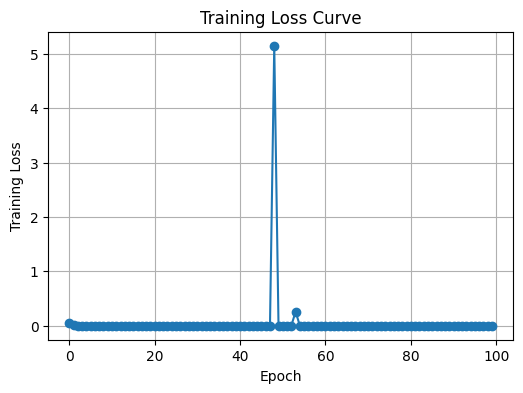

In [ ]:
# Training loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [ ]:
# Evaluate on hold-out test set
model.eval()
with torch.no_grad():
    outputs = model(X_test_t).squeeze()
    probs_test = torch.sigmoid(outputs).cpu().numpy()
    y_true_test = y_test_t.cpu().numpy()

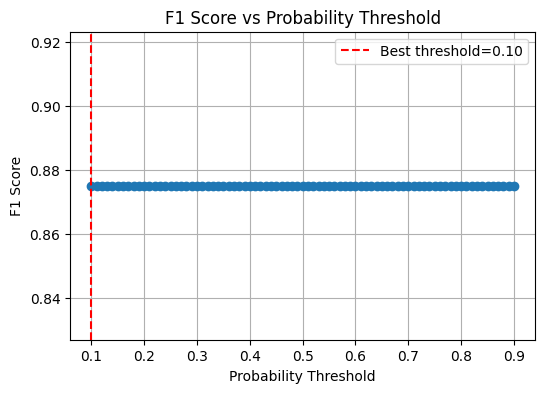


Best threshold for model outputs: 0.10
F1 score on test set: 0.8750


In [ ]:
# Best test f1 score and threshold
best_thresh_test, best_f1_test, f1_scores = find_best_threshold(y_true_test, probs_test, thresholds)

y_pred_test = (probs_test >= best_thresh_test).astype(int)

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_thresh_test, color='r', linestyle='--', label=f"Best threshold={best_thresh_test:.2f}")
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Probability Threshold")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nBest threshold for model outputs: {best_thresh_test:.2f}")
print(f"F1 score on test set: {best_f1_test:.4f}")

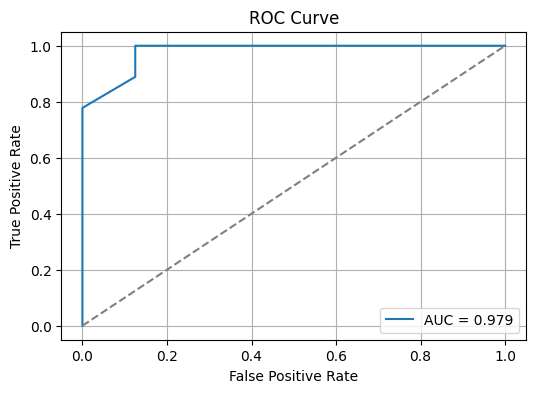

In [ ]:
# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true_test, probs_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

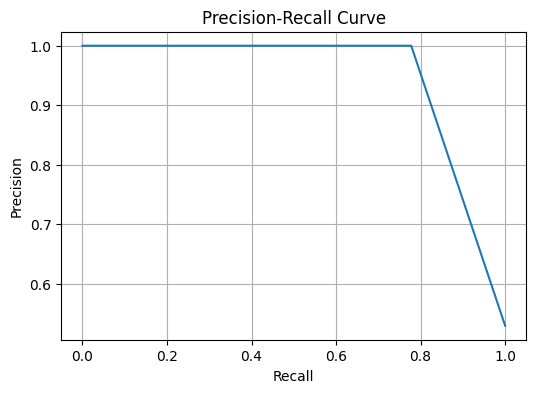

In [ ]:
# Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_true_test, y_pred_test)
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [ ]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_test))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.78      0.88         9

    accuracy                           0.88        17
   macro avg       0.90      0.89      0.88        17
weighted avg       0.91      0.88      0.88        17



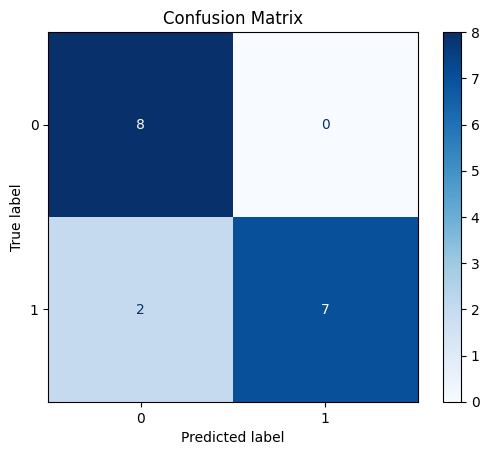

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
